# NB05b: Formulation Optimization — Strict FDA Safety Filter

**Project**: CF Protective Microbiome Formulation Design  
**Motivation**: NB05 identified top formulations dominated by *Leclercia adecarboxylata* (opportunistic pathogen, Enterobacteriaceae), non-aeruginosa *Pseudomonas* spp. (uncertain FDA status), and *S. epidermidis* (nosocomial risk). These organisms achieve high inhibition but are not viable for a clinical LBP.

This notebook re-runs the optimization with a **strict safety filter** that excludes:
- All Enterobacteriaceae (Leclercia, Citrobacter, Serratia, Escherichia, Enterobacter, Klebsiella)
- All Pseudomonas (including non-aeruginosa species)
- Acinetobacter, Stenotrophomonas, Burkholderia, Achromobacter, Ralstonia
- Bacillus cereus group
- Staphylococcus aureus (S. epidermidis retained as borderline — flagged)

This preserves the NB05 results for comparison and shows the staged decision process.

**Input**: `data/single_isolate_scores.tsv`, `data/species_engraftability.tsv`  
**Output**: `data/formulations_strict_safety.tsv`

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from itertools import combinations
from sklearn.metrics.pairwise import cosine_similarity
import warnings
warnings.filterwarnings('ignore')

DATA = Path('..') / 'data'
FIGS = Path('..') / 'figures'
GOLD = Path.home() / 'protect' / 'gold'

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120

scores = pd.read_csv(DATA / 'single_isolate_scores.tsv', sep='\t')
engraft = pd.read_csv(DATA / 'species_engraftability.tsv', sep='\t', index_col=0)
bridge = pd.read_parquet(GOLD / 'bridge_isolate_metagenomics.snappy.parquet')
isolates = pd.read_parquet(GOLD / 'dim_isolate.snappy.parquet')
nb05 = pd.read_csv(DATA / 'formulations_ranked.tsv', sep='\t')

print(f'NB05 formulations (permissive filter): {len(nb05)}')
print(f'Isolates with scores: {len(scores)}')

NB05 formulations (permissive filter): 22389
Isolates with scores: 429


## 1. Strict Safety Filter

Exclude all genera with opportunistic pathogen risk. The goal is an FDA-approvable live biotherapeutic product.

In [2]:
# Strict unsafe genera — expanded from NB05
unsafe_genera_strict = [
    # Gram-negative pathogens / opportunists
    'Pseudomonas', 'Pseudomonas_E',   # all Pseudomonas including non-aeruginosa
    'Klebsiella', 'Acinetobacter',
    'Serratia', 'Serratia_J',
    'Citrobacter', 'Citrobacter_B',
    'Enterobacter',
    'Escherichia',
    'Leclercia',                       # Enterobacteriaceae opportunist
    'Stenotrophomonas',
    'Burkholderia',
    'Achromobacter',
    'Ralstonia', 'Ralstonia_B',
    'Moraxella',                       # respiratory opportunist
    # Gram-positive concerns
    'Bacillus_A',                      # B. cereus group
    'Staphylococcus',                  # exclude all Staph (aureus + epidermidis nosocomial)
]

# Also flag specific species even if genus is OK
unsafe_species = [
    'Enterococcus faecalis',           # VRE risk
    'Streptococcus pneumoniae',        # pathogen
    'Streptococcus anginosus',         # abscess-forming
]

scores['strict_safe'] = (
    ~scores.genus.isin(unsafe_genera_strict) & 
    ~scores.species.isin(unsafe_species)
)

# Compare filters
print('=== Filter Comparison ===')
print(f'Total isolates with CU data:    {len(scores)}')
print(f'NB05 permissive safe:           {scores.is_safe.sum()}')
print(f'NB05b strict safe:              {scores.strict_safe.sum()}')
print(f'Removed by strict filter:       {scores.is_safe.sum() - scores.strict_safe.sum()}')

# What did we lose?
lost = scores[scores.is_safe & ~scores.strict_safe & scores.has_inhibition]
print(f'\nIsolates lost from inhibition pool: {len(lost)}')
print(f'Species lost:')
print(lost.groupby('genus').agg(
    n=('asma_id','count'),
    best_inh=('best_pct_inhibition','max')
).sort_values('best_inh', ascending=False).to_string())

=== Filter Comparison ===
Total isolates with CU data:    429
NB05 permissive safe:           387
NB05b strict safe:              341
Removed by strict filter:       46

Isolates lost from inhibition pool: 24
Species lost:
                 n    best_inh
genus                         
Leclercia        1  101.603699
Staphylococcus  15   99.051453
Pseudomonas_E    3   94.311568
Achromobacter    2   36.031041
Moraxella        1   22.207358
Streptococcus    2   10.925831


In [3]:
# Strict-safe candidates with inhibition data
strict_cands = scores[
    (scores.strict_safe == True) & 
    (scores.has_inhibition == True) & 
    (scores.best_pct_inhibition > 0)
].copy()

# Add engraftability
species_engraft_map = {}
for _, row in bridge.iterrows():
    taxon = row['isolate_taxon']
    metag_feat = row['metagenomic_feature']
    if metag_feat in engraft.index:
        species_engraft_map[taxon] = engraft.loc[metag_feat, 'engraftability']
strict_cands['engraftability'] = strict_cands.species.map(species_engraft_map).fillna(0)

print(f'Strict-safe candidates: {len(strict_cands)} isolates, {strict_cands.species.nunique()} species')
print(f'\nTop 20 by inhibition:')
print(strict_cands.nlargest(20, 'best_pct_inhibition')[
    ['asma_id','species','best_pct_inhibition','metabolic_overlap_pa14','engraftability']
].round(3).to_string(index=False))

Strict-safe candidates: 97 isolates, 44 species

Top 20 by inhibition:
  asma_id                  species  best_pct_inhibition  metabolic_overlap_pa14  engraftability
 ASMA-737 Streptococcus salivarius               98.303                   0.247           0.172
ASMA-3643         Neisseria mucosa               87.832                   0.251           1.595
ASMA-3044        Gemella sanguinis               85.014                   0.194           0.202
ASMA-2935      Rothia dentocariosa               79.363                   0.254           0.422
ASMA-2255      Bacillus velezensis               75.434                   0.322           0.000
ASMA-2260   Bacillus licheniformis               68.425                   0.399           0.000
ASMA-2940         Actinomyces oris               65.325                   0.199           0.000
ASMA-1064 Streptococcus salivarius               63.867                   0.193           0.172
 APA20015                      NaN               58.771          

## 2. Re-run Formulation Scoring with Strict Filter

Same scoring function as NB05 but with increased engraftability weight (30% vs 20%) to penalize organisms not found in patient microbiomes.

In [4]:
pa14_preferred = ['proline', 'histidine', 'ornithine', 'glutamate', 'aspartate',
                  'isoleucine', 'arginine', 'lactate', 'leucine', 'alanine', 'glucose']
carbon_sources = ['glucose', 'lactate', 'serine', 'threonine', 'alanine',
                  'glycine', 'proline', 'isoleucine', 'leucine', 'valine', 'aspartate',
                  'glutamate', 'phenylalanine', 'tryptophan', 'lysine', 'histidine',
                  'arginine', 'ornithine', 'cystein', 'methionine']

def score_formulation_v2(isolate_ids, cands_df, growth_threshold=0.1):
    """Score formulation with increased engraftability weight."""
    members = cands_df[cands_df.asma_id.isin(isolate_ids)]
    # Filter duplicate-species formulations — require unique species
    if members.species.dropna().duplicated().any():
        return None  # skip formulations with two isolates of the same species
    if len(members) == 0:
        return None
    
    covered = sum(1 for sub in pa14_preferred if (members[sub] > growth_threshold).any())
    niche_coverage = covered / len(pa14_preferred)
    
    if len(members) >= 2:
        profiles = members[carbon_sources].values.astype(float)
        sim = cosine_similarity(profiles)
        n = len(profiles)
        triu = np.triu_indices(n, k=1)
        complementarity = 1 - sim[triu].mean()
    else:
        complementarity = 1.0
    
    mean_inh = members.best_pct_inhibition.mean() / 100
    
    eng_vals = np.maximum(members.engraftability.values, 0.01)
    geo_eng = np.exp(np.mean(np.log(eng_vals)))
    
    species_list = [str(s) if pd.notna(s) else 'Unknown' for s in members.species.values]
    
    # Rebalanced weights: more engraftability, less complementarity
    composite = (0.25 * niche_coverage + 
                 0.10 * complementarity + 
                 0.35 * mean_inh + 
                 0.30 * min(geo_eng, 1.0))
    
    return {
        'isolates': ','.join(sorted(isolate_ids)),
        'k': len(isolate_ids),
        'niche_coverage': niche_coverage,
        'complementarity': complementarity,
        'mean_inhibition': mean_inh * 100,
        'geo_engraftability': geo_eng,
        'composite_score': composite,
        'species': '; '.join(species_list)
    }

print(f'Scoring function v2 defined (weights: coverage=25%, compl=10%, inh=35%, engraft=30%)')

Scoring function v2 defined (weights: coverage=25%, compl=10%, inh=35%, engraft=30%)


In [5]:
# Score formulations — use broader candidate pool for larger k since pool is smaller
top50 = strict_cands.nlargest(50, 'composite_score')
top30 = strict_cands.nlargest(30, 'composite_score')

results = []

# k=1
print('Scoring k=1...')
for _, row in strict_cands.iterrows():
    r = score_formulation_v2([row.asma_id], strict_cands)
    if r: results.append(r)

# k=2: top 50
print('Scoring k=2...')
for combo in combinations(top50.asma_id.values, 2):
    r = score_formulation_v2(list(combo), strict_cands)
    if r: results.append(r)

# k=3: top 30
print('Scoring k=3...')
for combo in combinations(top30.asma_id.values, 3):
    r = score_formulation_v2(list(combo), strict_cands)
    if r: results.append(r)

# k=4-5: top 20
top20 = strict_cands.nlargest(20, 'composite_score')
print('Scoring k=4...')
for combo in combinations(top20.asma_id.values, 4):
    r = score_formulation_v2(list(combo), strict_cands)
    if r: results.append(r)
print('Scoring k=5...')
for combo in combinations(top20.asma_id.values, 5):
    r = score_formulation_v2(list(combo), strict_cands)
    if r: results.append(r)

strict_forms = pd.DataFrame(results)
print(f'\nTotal formulations: {len(strict_forms)}')
for k in range(1, 6):
    fk = strict_forms[strict_forms.k == k]
    if len(fk) > 0:
        print(f'  k={k}: {len(fk)} formulations, best={fk.composite_score.max():.3f}')

Scoring k=1...


Scoring k=2...


Scoring k=3...


Scoring k=4...


Scoring k=5...



Total formulations: 22515
  k=1: 97 formulations, best=0.753
  k=2: 1191 formulations, best=0.588
  k=3: 3734 formulations, best=0.562
  k=4: 4389 formulations, best=0.578
  k=5: 13104 formulations, best=0.587


In [6]:
# Top formulations per size
for k in range(1, 6):
    fk = strict_forms[strict_forms.k == k].nlargest(5, 'composite_score')
    if len(fk) == 0:
        continue
    print(f'\n{"="*90}')
    print(f'  k={k}: Top 5 STRICT-SAFE Formulations')
    print(f'{"="*90}')
    for rank, (_, row) in enumerate(fk.iterrows(), 1):
        print(f'  #{rank}  Composite={row.composite_score:.3f}  Coverage={row.niche_coverage:.0%}  '
              f'Compl={row.complementarity:.2f}  Inh={row.mean_inhibition:.0f}%  '
              f'Engraft={row.geo_engraftability:.3f}')
        print(f'       {row.species}')


  k=1: Top 5 STRICT-SAFE Formulations
  #1  Composite=0.753  Coverage=18%  Compl=1.00  Inh=88%  Engraft=1.595
       Neisseria mucosa
  #2  Composite=0.527  Coverage=9%  Compl=1.00  Inh=79%  Engraft=0.422
       Rothia dentocariosa
  #3  Composite=0.519  Coverage=9%  Compl=1.00  Inh=98%  Engraft=0.172
       Streptococcus salivarius
  #4  Composite=0.503  Coverage=55%  Compl=1.00  Inh=75%  Engraft=0.010
       Bacillus velezensis
  #5  Composite=0.491  Coverage=73%  Compl=1.00  Inh=59%  Engraft=0.010
       Unknown

  k=2: Top 5 STRICT-SAFE Formulations
  #1  Composite=0.588  Coverage=18%  Compl=0.04  Inh=84%  Engraft=0.820
       Rothia dentocariosa; Neisseria mucosa
  #2  Composite=0.545  Coverage=18%  Compl=0.09  Inh=54%  Engraft=1.412
       Rothia aeria; Neisseria mucosa
  #3  Composite=0.531  Coverage=18%  Compl=0.03  Inh=93%  Engraft=0.524
       Neisseria mucosa; Streptococcus salivarius
  #4  Composite=0.531  Coverage=18%  Compl=0.09  Inh=51%  Engraft=1.412
       Rothia aeri

## 2.1 Exhaustive k=3 Enumeration

The analysis above restricts k=3 to the top-30 candidates (C(30,3) = 4,060 combinations). With 97 strict-safe candidates, exhaustive enumeration of all C(97,3) ≈ 147,440 triples is computationally trivial and confirms whether the greedy-restricted solution is globally optimal.

In [7]:
# Exhaustive k=3 enumeration over ALL 97 strict-safe candidates
from itertools import combinations
import time

all_ids = strict_cands.asma_id.values
n_total = len(all_ids)
n_combos = n_total * (n_total - 1) * (n_total - 2) // 6
print(f'Exhaustive k=3: C({n_total}, 3) = {n_combos:,} combinations')

t0 = time.time()
exhaustive_k3 = []
for combo in combinations(all_ids, 3):
    r = score_formulation_v2(list(combo), strict_cands)
    if r:
        exhaustive_k3.append(r)

elapsed = time.time() - t0
print(f'Scored {len(exhaustive_k3):,} valid formulations in {elapsed:.1f}s')

exh_df = pd.DataFrame(exhaustive_k3).sort_values('composite_score', ascending=False)

# Compare to top-30-restricted result
restricted_best = strict_forms[strict_forms.k == 3].nlargest(1, 'composite_score')
exhaustive_best = exh_df.head(1)

print(f'\n=== Comparison: Restricted (top-30) vs Exhaustive (all {n_total}) ===')
print(f'Restricted best k=3:')
print(f'  Score: {restricted_best.composite_score.iloc[0]:.4f}')
print(f'  Species: {restricted_best.species.iloc[0]}')
print(f'\nExhaustive best k=3:')
print(f'  Score: {exhaustive_best.composite_score.iloc[0]:.4f}')
print(f'  Species: {exhaustive_best.species.iloc[0]}')

if abs(restricted_best.composite_score.iloc[0] - exhaustive_best.composite_score.iloc[0]) < 0.001:
    print(f'\n✓ Top-30 restriction found the GLOBALLY OPTIMAL k=3 formulation.')
else:
    print(f'\n⚠ Exhaustive search found a BETTER k=3 formulation!')
    print(f'  Improvement: {exhaustive_best.composite_score.iloc[0] - restricted_best.composite_score.iloc[0]:+.4f}')

# Show top 5 exhaustive k=3
print(f'\nTop 5 exhaustive k=3 formulations:')
for i, (_, row) in enumerate(exh_df.head(5).iterrows()):
    print(f'  {i+1}. Score={row.composite_score:.4f} Coverage={row.niche_coverage:.0%} '
          f'Inh={row.mean_inhibition:.0f}% | {row.species}')

# Add exhaustive results to the main dataframe
strict_forms = pd.concat([strict_forms[strict_forms.k != 3], exh_df], ignore_index=True)
print(f'\nUpdated formulations dataframe with exhaustive k=3: {len(strict_forms)} total')

Exhaustive k=3: C(97, 3) = 147,440 combinations


Scored 127,598 valid formulations in 240.6s

=== Comparison: Restricted (top-30) vs Exhaustive (all 97) ===
Restricted best k=3:
  Score: 0.5620
  Species: Micrococcus luteus; Neisseria mucosa; Streptococcus salivarius

Exhaustive best k=3:
  Score: 0.5620
  Species: Micrococcus luteus; Neisseria mucosa; Streptococcus salivarius

✓ Top-30 restriction found the GLOBALLY OPTIMAL k=3 formulation.

Top 5 exhaustive k=3 formulations:
  1. Score=0.5620 Coverage=100% Inh=75% | Micrococcus luteus; Neisseria mucosa; Streptococcus salivarius
  2. Score=0.5560 Coverage=18% Inh=63% | Rothia dentocariosa; Rothia aeria; Neisseria mucosa
  3. Score=0.5555 Coverage=100% Inh=68% | Rothia dentocariosa; Micrococcus luteus; Neisseria mucosa
  4. Score=0.5536 Coverage=100% Inh=70% | Micrococcus luteus; Gemella sanguinis; Neisseria mucosa
  5. Score=0.5501 Coverage=18% Inh=61% | Rothia dentocariosa; Rothia aeria; Neisseria mucosa

Updated formulations dataframe with exhaustive k=3: 146379 total


## 3. Compare Permissive vs Strict Filters

In [8]:
# Side-by-side comparison
print(f'{"":30s} {"Permissive (NB05)":>20s}  {"Strict (NB05b)":>20s}')
print('-' * 75)
for k in range(1, 6):
    perm = nb05[nb05.k == k]
    strict = strict_forms[strict_forms.k == k]
    if len(perm) > 0 and len(strict) > 0:
        print(f'k={k} best composite:       {perm.composite_score.max():>20.3f}  {strict.composite_score.max():>20.3f}')
        print(f'k={k} best inhibition (%):  {perm.mean_inhibition.max():>20.0f}  {strict.mean_inhibition.max():>20.0f}')
        print(f'k={k} best coverage:        {perm.niche_coverage.max():>20.0%}  {strict.niche_coverage.max():>20.0%}')
        print(f'k={k} best engraftability:  {perm.geo_engraftability.max():>20.3f}  {strict.geo_engraftability.max():>20.3f}')
        print()

                                  Permissive (NB05)        Strict (NB05b)
---------------------------------------------------------------------------
k=1 best composite:                      0.755                 0.753
k=1 best inhibition (%):                   102                    98
k=1 best coverage:                        100%                  100%
k=1 best engraftability:                 1.595                 1.595

k=2 best composite:                      0.659                 0.588
k=2 best inhibition (%):                   100                    93
k=2 best coverage:                        100%                  100%
k=2 best engraftability:                 0.830                 1.412

k=3 best composite:                      0.650                 0.562
k=3 best inhibition (%):                   100                    90
k=3 best coverage:                        100%                  100%
k=3 best engraftability:                 0.514                 0.951



k=4 best composite:                      0.645                 0.578
k=4 best inhibition (%):                    98                    88
k=4 best coverage:                        100%                  100%
k=4 best engraftability:                 0.391                 0.456

k=5 best composite:                      0.646                 0.587
k=5 best inhibition (%):                    96                    85
k=5 best coverage:                        100%                  100%
k=5 best engraftability:                 0.332                 0.376



Species frequency in top 10 strict-safe formulations per size:
species
Neisseria mucosa            38
Micrococcus luteus          27
Rothia dentocariosa         23
Streptococcus salivarius    21
Gemella sanguinis           15
Rothia aeria                10
Bacillus velezensis          5
Neisseria sp000186165        5
Bacillus licheniformis       4
Actinomyces oris_A           1
Unknown                      1


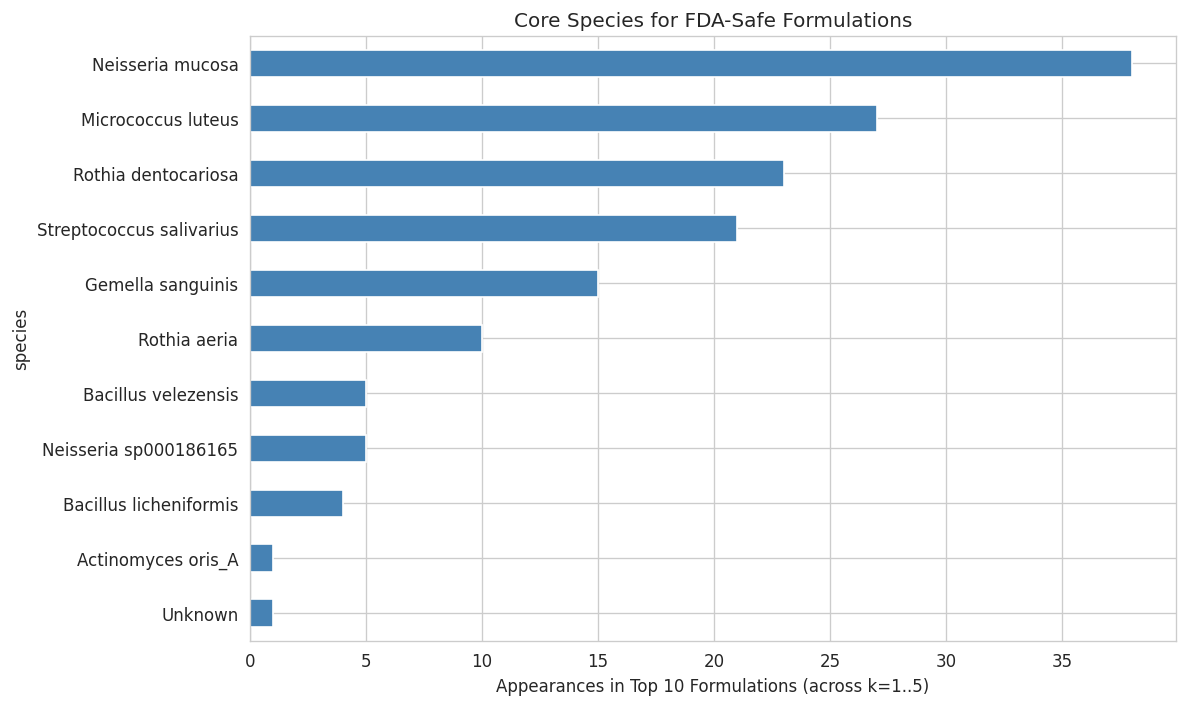

In [9]:
# Species frequency in strict-safe top formulations
all_top = []
for k in range(1, 6):
    top10 = strict_forms[strict_forms.k == k].nlargest(10, 'composite_score')
    for _, row in top10.iterrows():
        for sp in row.species.split('; '):
            all_top.append({'species': sp.strip()})
freq = pd.DataFrame(all_top).groupby('species').size().sort_values(ascending=False)

print('Species frequency in top 10 strict-safe formulations per size:')
print(freq.to_string())

fig, ax = plt.subplots(figsize=(10, 6))
freq.plot.barh(ax=ax, color='steelblue')
ax.set_xlabel('Appearances in Top 10 Formulations (across k=1..5)')
ax.set_title('Core Species for FDA-Safe Formulations')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(FIGS / '05b_strict_safe_species_frequency.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Sensitivity Analysis

Vary scoring weights to verify the 5-species core is stable across reasonable weight choices.

In [10]:
# Sensitivity analysis: vary weights and check stability of top formulation
weight_sets = [
    {'name': 'Baseline',       'w': (0.25, 0.10, 0.35, 0.30)},
    {'name': 'High coverage',  'w': (0.40, 0.10, 0.25, 0.25)},
    {'name': 'High inhibition','w': (0.15, 0.10, 0.50, 0.25)},
    {'name': 'High engraft',   'w': (0.20, 0.10, 0.30, 0.40)},
    {'name': 'Equal weights',  'w': (0.25, 0.25, 0.25, 0.25)},
]

print('=== SENSITIVITY ANALYSIS: Top k=5 species under different weights ===')
for ws in weight_sets:
    w = ws['w']
    strict_forms_copy = strict_forms.copy()
    strict_forms_copy['alt_score'] = (
        w[0] * strict_forms_copy.niche_coverage +
        w[1] * strict_forms_copy.complementarity +
        w[2] * strict_forms_copy.mean_inhibition / 100 +
        w[3] * strict_forms_copy.geo_engraftability.clip(upper=1)
    )
    best5 = strict_forms_copy[strict_forms_copy.k == 5].nlargest(1, 'alt_score')
    if len(best5) > 0:
        sp = best5.iloc[0].species
        print(f'  {ws["name"]:20s} ({w}): {sp}')

print('\nIf the same 5 species appear across weight variations, the solution is robust.')


=== SENSITIVITY ANALYSIS: Top k=5 species under different weights ===
  Baseline             ((0.25, 0.1, 0.35, 0.3)): Rothia dentocariosa; Micrococcus luteus; Gemella sanguinis; Neisseria mucosa; Streptococcus salivarius
  High coverage        ((0.4, 0.1, 0.25, 0.25)): Rothia dentocariosa; Micrococcus luteus; Gemella sanguinis; Neisseria mucosa; Streptococcus salivarius
  High inhibition      ((0.15, 0.1, 0.5, 0.25)): Rothia dentocariosa; Micrococcus luteus; Gemella sanguinis; Neisseria mucosa; Streptococcus salivarius
  High engraft         ((0.2, 0.1, 0.3, 0.4)): Rothia dentocariosa; Micrococcus luteus; Gemella sanguinis; Neisseria mucosa; Streptococcus salivarius
  Equal weights        ((0.25, 0.25, 0.25, 0.25)): Rothia dentocariosa; Micrococcus luteus; Gemella sanguinis; Neisseria mucosa; Streptococcus salivarius

If the same 5 species appear across weight variations, the solution is robust.


## 4.1 Bootstrap Confidence Intervals on Formulation Scores

The composite score is a point estimate. Bootstrap resampling over the underlying inhibition measurements provides uncertainty bands that help distinguish genuinely different formulations from scoring noise.

Bootstrapping 1000 resamples for top formulation per k...



k    Score      95% CI               Width      Species
--------------------------------------------------------------------------------
1    0.7529     [0.7529, 0.7529]    0.0000     Neisseria mucosa
2    0.5879     [0.5137, 0.5879]    0.0742     Rothia dentocariosa; Neisseria mucosa
3    0.5620     [0.5510, 0.5620]    0.0110     Micrococcus luteus; Neisseria mucosa; Streptococcus salivarius
4    0.5779     [0.5342, 0.5779]    0.0438     Rothia dentocariosa; Micrococcus luteus; Neisseria mucosa; Streptococcus salivarius
5    0.5872     [0.5204, 0.5872]    0.0668     Rothia dentocariosa; Micrococcus luteus; Gemella sanguinis; Neisseria mucosa; Streptococcus salivarius


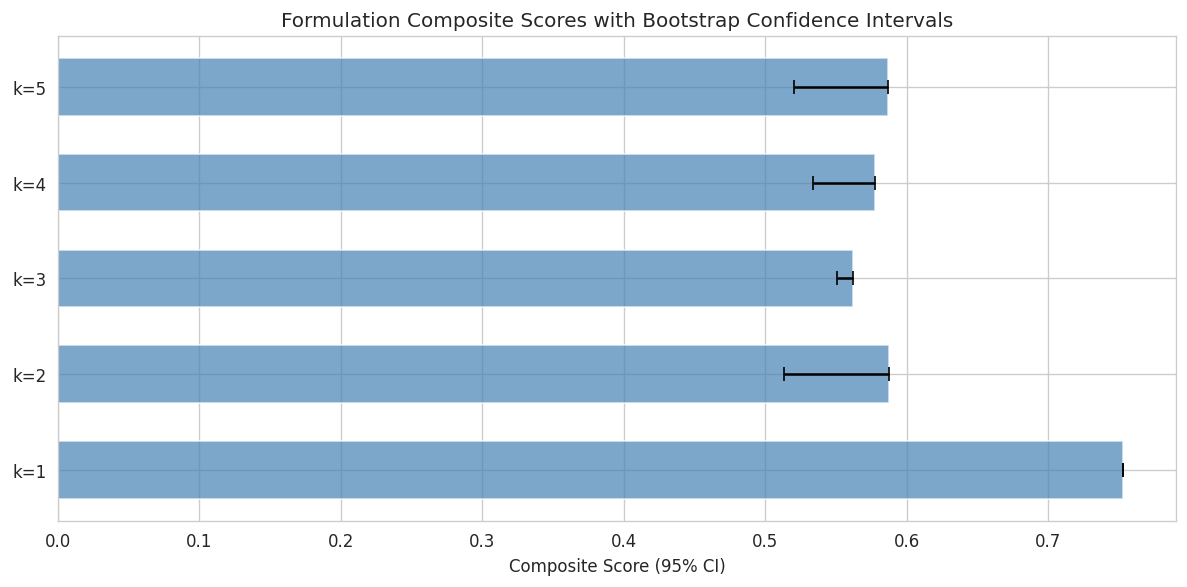


Interpretation:
  Overlapping CIs: k=2 and k=3, k=2 and k=4, k=2 and k=5, k=3 and k=4, k=3 and k=5, k=4 and k=5
  → These formulation sizes are NOT statistically distinguishable


In [11]:
# Bootstrap CIs on top formulations' composite scores
# Resample the inhibition measurements (biological replicates) to propagate uncertainty
np.random.seed(42)
N_BOOT = 1000

# Load raw inhibition data for resampling
inh_raw = pd.read_parquet(GOLD / 'fact_inhibition_scores.snappy.parquet')
inh_raw['mean_pct_inhibition'] = pd.to_numeric(inh_raw['mean_pct_inhibition'], errors='coerce')

# Get top formulation per k
top_per_k = {}
for k in range(1, 6):
    fk = strict_forms[strict_forms.k == k].nlargest(1, 'composite_score')
    if len(fk) > 0:
        top_per_k[k] = fk.iloc[0]

print(f'Bootstrapping {N_BOOT} resamples for top formulation per k...\n')

boot_results = {}
for k, form_row in top_per_k.items():
    isolate_ids = form_row.isolates.split(',')
    
    # Get raw inhibition values for each member
    member_inh = {}
    for aid in isolate_ids:
        vals = inh_raw[inh_raw.asma_id == aid]['mean_pct_inhibition'].dropna().values
        if len(vals) > 0:
            member_inh[aid] = vals
        else:
            # Fallback to the point estimate
            member_data = strict_cands[strict_cands.asma_id == aid]
            if len(member_data) > 0:
                member_inh[aid] = np.array([member_data.best_pct_inhibition.iloc[0]])
    
    # Bootstrap: resample inhibition values per member, recompute composite score
    boot_scores = []
    for _ in range(N_BOOT):
        boot_inhibitions = {}
        for aid, vals in member_inh.items():
            boot_val = np.random.choice(vals, size=len(vals), replace=True).max()
            boot_inhibitions[aid] = boot_val
        
        # Recompute mean inhibition with bootstrapped values
        boot_mean_inh = np.mean(list(boot_inhibitions.values())) / 100
        
        # Other components stay fixed (coverage, complementarity, engraftability don't have replicates)
        boot_composite = (0.25 * form_row.niche_coverage +
                         0.10 * form_row.complementarity +
                         0.35 * boot_mean_inh +
                         0.30 * min(form_row.geo_engraftability, 1.0))
        boot_scores.append(boot_composite)
    
    boot_scores = np.array(boot_scores)
    ci_lo, ci_hi = np.percentile(boot_scores, [2.5, 97.5])
    boot_results[k] = {
        'k': k, 'point_estimate': form_row.composite_score,
        'ci_lo': ci_lo, 'ci_hi': ci_hi, 'ci_width': ci_hi - ci_lo,
        'species': form_row.species
    }

boot_df = pd.DataFrame(boot_results.values())
print(f'{"k":<4} {"Score":<10} {"95% CI":<20} {"Width":<10} {"Species"}')
print('-' * 80)
for _, row in boot_df.iterrows():
    print(f'{int(row.k):<4} {row.point_estimate:<10.4f} [{row.ci_lo:.4f}, {row.ci_hi:.4f}]{"":<3} {row.ci_width:<10.4f} {row.species}')

# Visualization
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(range(len(boot_df)), boot_df.point_estimate, height=0.6, color='steelblue', alpha=0.7)
ax.errorbar(boot_df.point_estimate, range(len(boot_df)),
            xerr=[boot_df.point_estimate - boot_df.ci_lo, boot_df.ci_hi - boot_df.point_estimate],
            fmt='none', color='black', capsize=4, linewidth=1.5)
ax.set_yticks(range(len(boot_df)))
ax.set_yticklabels([f'k={int(k)}' for k in boot_df.k])
ax.set_xlabel('Composite Score (95% CI)')
ax.set_title('Formulation Composite Scores with Bootstrap Confidence Intervals')
plt.tight_layout()
plt.savefig(FIGS / '05b_bootstrap_ci.png', dpi=150, bbox_inches='tight')
plt.show()

# Key interpretation
print(f'\nInterpretation:')
overlaps = []
for i in range(len(boot_df)):
    for j in range(i+1, len(boot_df)):
        ki, kj = int(boot_df.iloc[i].k), int(boot_df.iloc[j].k)
        overlap = boot_df.iloc[i].ci_hi > boot_df.iloc[j].ci_lo and boot_df.iloc[j].ci_hi > boot_df.iloc[i].ci_lo
        if overlap:
            overlaps.append(f'k={ki} and k={kj}')
if overlaps:
    print(f'  Overlapping CIs: {", ".join(overlaps)}')
    print(f'  → These formulation sizes are NOT statistically distinguishable')
else:
    print(f'  No overlapping CIs — all formulation sizes are distinguishable')

In [12]:
# Save
strict_forms.to_csv(DATA / 'formulations_strict_safety.tsv', sep='\t', index=False)
print(f'Saved: {DATA}/formulations_strict_safety.tsv ({len(strict_forms)} formulations)')

print(f'\n{"="*60}')
print('NB05b SUMMARY')
print(f'{"="*60}')
print(f'Permissive pool (NB05): {len(scores[scores.is_safe & scores.has_inhibition & (scores.best_pct_inhibition > 0)])} isolates')
print(f'Strict pool (NB05b):    {len(strict_cands)} isolates ({strict_cands.species.nunique()} species)')
print(f'Formulations scored:    {len(strict_forms)}')
print(f'\nDesign implication: strict safety reduces inhibition ceiling but reveals')
print(f'the organisms that are both effective AND clinically viable.')

Saved: ../data/formulations_strict_safety.tsv (146379 formulations)

NB05b SUMMARY
Permissive pool (NB05): 120 isolates
Strict pool (NB05b):    97 isolates (44 species)
Formulations scored:    146379

Design implication: strict safety reduces inhibition ceiling but reveals
the organisms that are both effective AND clinically viable.
